In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [6]:
ocr_path = r"C:\Users\Priyanka\OneDrive\Desktop\metadata_ocr.csv"

ocr_df = pd.read_csv(ocr_path)

print("Total rows:", len(ocr_df))
print("\nColumns:")
print(ocr_df.columns.tolist())

print("\nFirst 5 rows:")
display(ocr_df.head())

Total rows: 2392

Columns:
['filename', 'category', 'filepath', 'ocr_text']

First 5 rows:


,filename,category,filepath,ocr_text
0,IMG-20260813-WA0638.jpg,Addresses_Locations,C:\Users\Priyanka\OneDrive\Desktop\Smart_Scree...,2.05 PM kina Tickel19.7KBIs % B #l Trip Detail...
1,IMG-20260813-WA0640.jpg,Addresses_Locations,C:\Users\Priyanka\OneDrive\Desktop\Smart_Scree...,2.05 PM kina Tickel 146KBIs % B #l E84.95 Than...
2,IMG-20260813-WA0645.jpg,Addresses_Locations,C:\Users\Priyanka\OneDrive\Desktop\Smart_Scree...,2.05 PM 22.3KB/s 4 @ #ll 08 2 KBIs Hellol Look...
3,IMG-20260813-WA0648.jpg,Addresses_Locations,C:\Users\Priyanka\OneDrive\Desktop\Smart_Scree...,2.05 PM 56.2KB/s 4 @ #ll :48 LTE Confirmation ...
4,IMG-20260813-WA0653.jpg,Addresses_Locations,C:\Users\Priyanka\OneDrive\Desktop\Smart_Scree...,2.05 PM 31.2KB/s 4 @ dqll Your next gtoy The C...


In [5]:
# Import required libraries
from sentence_transformers import SentenceTransformer
import torch

# Select GPU if available
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)

# Load semantic search model
model = SentenceTransformer("all-MiniLM-L6-v2", device=device)

print("Semantic model loaded successfully!")

C:\Users\Priyanka\screenshot_gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


C:\Users\Priyanka\screenshot_gpu\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Priyanka\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 10265.50it/s]


Semantic model loaded successfully!


In [7]:
# Get OCR text
texts = ocr_df["ocr_text"].fillna("").astype(str).tolist()

print("Total texts:", len(texts))

# Generate semantic embeddings
embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)

Total texts: 2392


Batches: 100%|██████████| 75/75 [00:03<00:00, 18.77it/s]

Embedding shape: (2392, 384)


In [8]:
import numpy as np

# Save semantic embeddings
embeddings_path = r"C:\Users\Priyanka\OneDrive\Desktop\screenshot_embeddings.npy"

np.save(embeddings_path, embeddings)

print("Embeddings saved successfully!")
print("Shape:", embeddings.shape)

Embeddings saved successfully!
Shape: (2392, 384)


In [9]:
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, top_k=5):
    # Convert query into an embedding
    query_embedding = model.encode(
        [query],
        convert_to_numpy=True
    )

    # Calculate similarity with all screenshots
    similarities = cosine_similarity(
        query_embedding,
        embeddings
    )[0]

    # Get top matching screenshots
    top_indices = similarities.argsort()[-top_k:][::-1]

    results = ocr_df.iloc[top_indices].copy()
    results["similarity"] = similarities[top_indices]

    return results[["filename", "category", "similarity", "ocr_text"]]

In [10]:
semantic_search("payment", top_k=5)

,filename,category,similarity,ocr_text
1607,IMG-20260813-WA0792.jpg,Receipts_Bills,0.550429,YOUR NO; 0oooo1 Loco INVOICE Date: 02 June; 20...
1553,IMG-20260813-WA0723.jpg,Receipts_Bills,0.531213,07 Payment Receipt SELLER INFORMATION: NAME: [...
1618,IMG-20260813-WA0805.jpg,Receipts_Bills,0.483636,PAYMENT RECEIPT UK ELECTRONIC STORE Kiruspubli...
320,IMG-20260813-WA1584.jpg,Addresses_Locations,0.482799,4:16 PM 291KB/s @ A+ 16 # REC E |PT No; Date R...
130,IMG-20260813-WA1378.jpg,Addresses_Locations,0.462025,4331 PM 158KB/s c 401 Iail INVESTOBAZAR WEALTH...


In [48]:
def semantic_search(query, top_k=5):

    # Convert query into an embedding
    query_embedding = model.encode(
        [query],
        convert_to_numpy=True
    )

    # Calculate semantic similarity
    similarities = cosine_similarity(
        query_embedding,
        embeddings
    )[0]

    search_df = ocr_df.copy()
    search_df["similarity"] = similarities

    query_lower = query.lower().strip()

    # --------------------------------------------------
    # 1. Detect the intended category
    # --------------------------------------------------

    matched_category = None

    # Strong phrases first
    if any(word in query_lower for word in [
        "shopping bill",
        "purchase bill",
        "payment bill",
        "store bill",
        "shop bill",
        "restaurant bill",
        "electricity bill",
        "water bill",
        "invoice",
        "receipt",
        "payment receipt",
        "purchase receipt",
        "bill"
    ]):
        matched_category = "Receipts_Bills"

    elif any(word in query_lower for word in [
        "product shopping",
        "shopping product",
        "product",
        "product price",
        "product details",
        "buy product",
        "want to buy",
        "shopping item",
        "item to buy"
    ]):
        matched_category = "Products_Shopping"

    elif any(word in query_lower for word in [
        "address",
        "location",
        "map",
        "directions",
        "place",
        "where is"
    ]):
        matched_category = "Addresses_Locations"

    elif any(word in query_lower for word in [
        "interior",
        "home design",
        "room design",
        "bedroom",
        "living room",
        "kitchen design",
        "home decoration"
    ]):
        matched_category = "Interior_Design"

    elif any(word in query_lower for word in [
        "recipe",
        "cooking",
        "ingredients",
        "dish",
        "food recipe",
        "cake recipe"
    ]):
        matched_category = "Recipes"

    elif any(word in query_lower for word in [
        "ticket",
        "booking",
        "reservation",
        "flight",
        "train ticket",
        "bus ticket",
        "hotel booking",
        "movie ticket"
    ]):
        matched_category = "Tickets_Bookings"

    # --------------------------------------------------
    # 2. Strongly boost the intended category
    # --------------------------------------------------

    if matched_category is not None:

        search_df.loc[
            search_df["category"] == matched_category,
            "similarity"
        ] += 1.0

    # --------------------------------------------------
    # 3. Sort and return top results
    # --------------------------------------------------

    results = search_df.sort_values(
        by="similarity",
        ascending=False
    ).head(top_k)

    return results[[
        "filename",
        "category",
        "filepath",
        "similarity",
        "ocr_text"
    ]]

In [49]:
from PIL import Image
import matplotlib.pyplot as plt

def show_search_results(results):
    for _, row in results.iterrows():
        try:
            image = Image.open(row["filepath"])

            plt.figure(figsize=(6, 4))
            plt.imshow(image)
            plt.axis("off")
            plt.title(
                f'{row["filename"]} | {row["category"]} | '
                f'Similarity: {row["similarity"]:.3f}'
            )
            plt.show()

        except Exception as e:
            print("Could not open:", row["filename"])
            print("Error:", e)

In [50]:
def search_and_show(query, top_k=3):
    print("Search query:", query)
    
    results = semantic_search(query, top_k)
    
    display(results[["filename", "category", "similarity"]])
    
    show_search_results(results)

Search query: product shopping


,filename,category,similarity
1156,IMG-20260813-WA1153.jpg,Products_Shopping,1.358110
1173,IMG-20260813-WA1170.jpg,Products_Shopping,1.344991
1182,IMG-20260813-WA1179.jpg,Products_Shopping,1.343463


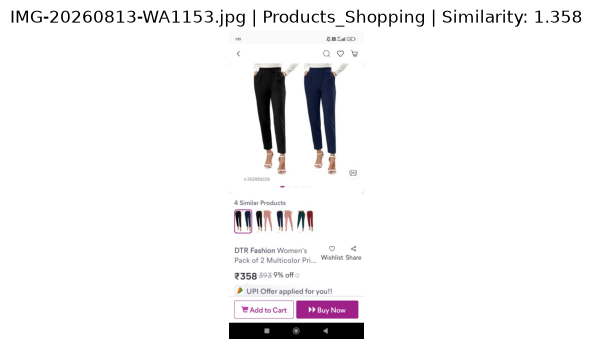

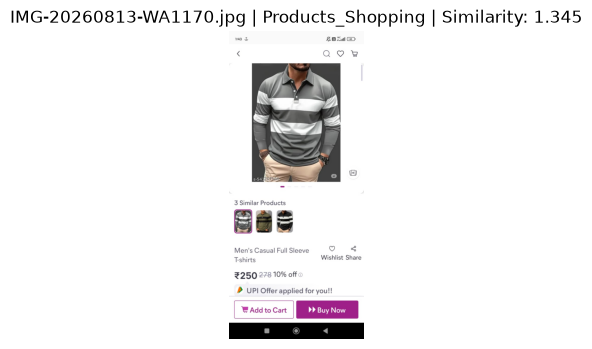

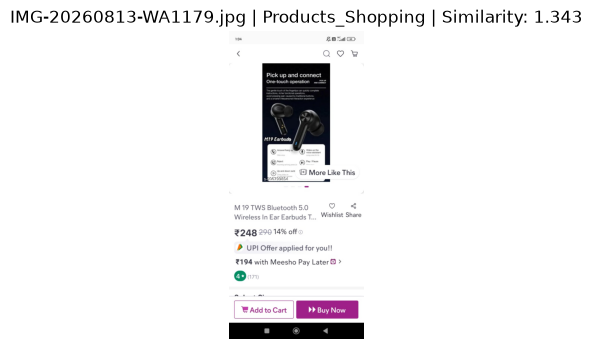

Search query: shopping bill


,filename,category,similarity
1607,IMG-20260813-WA0792.jpg,Receipts_Bills,1.488224
1556,IMG-20260813-WA0726.jpg,Receipts_Bills,1.484799
1558,IMG-20260813-WA0729.jpg,Receipts_Bills,1.469825


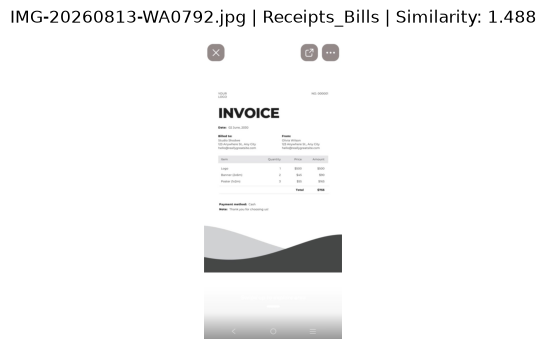

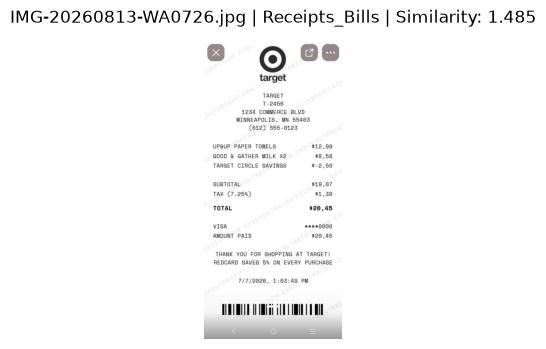

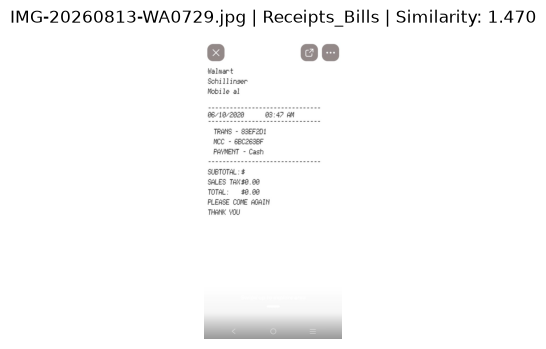

Search query: address location


,filename,category,similarity
289,IMG-20260813-WA1540.jpg,Addresses_Locations,1.611934
132,IMG-20260813-WA1380.jpg,Addresses_Locations,1.610214
17,IMG-20260813-WA1263.jpg,Addresses_Locations,1.556921


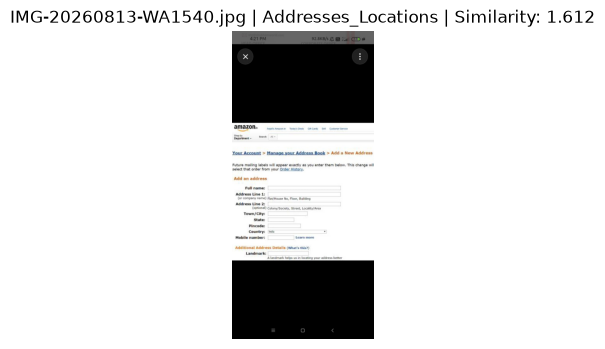

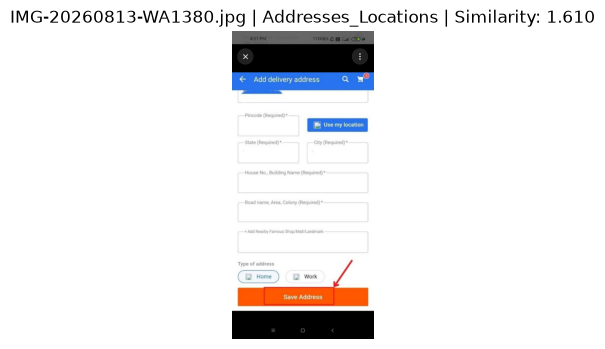

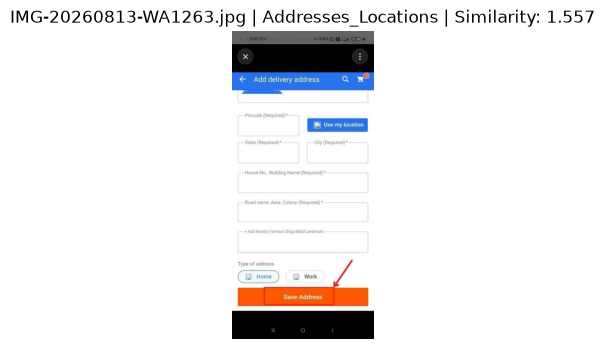

Search query: recipe


,filename,category,similarity
1830,Screenshot_2026-08-13-14-41-33-85_40deb401b9ff...,Recipes,1.580940
1814,Screenshot_2026-08-13-14-38-02-10_40deb401b9ff...,Recipes,1.580625
2010,Screenshot_2026-08-13-15-37-45-28_40deb401b9ff...,Recipes,1.568403


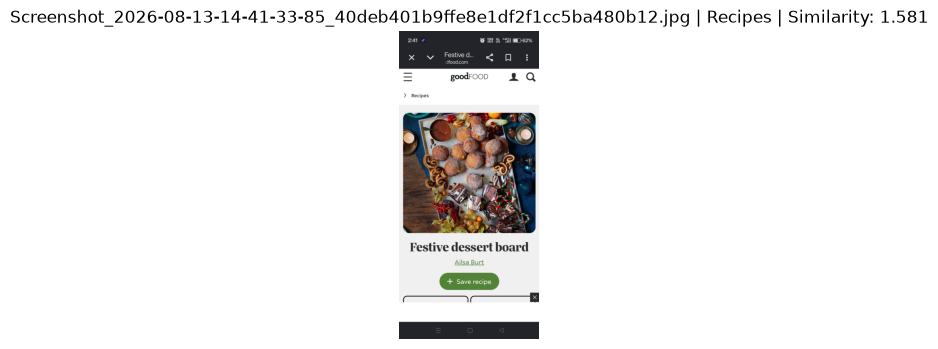

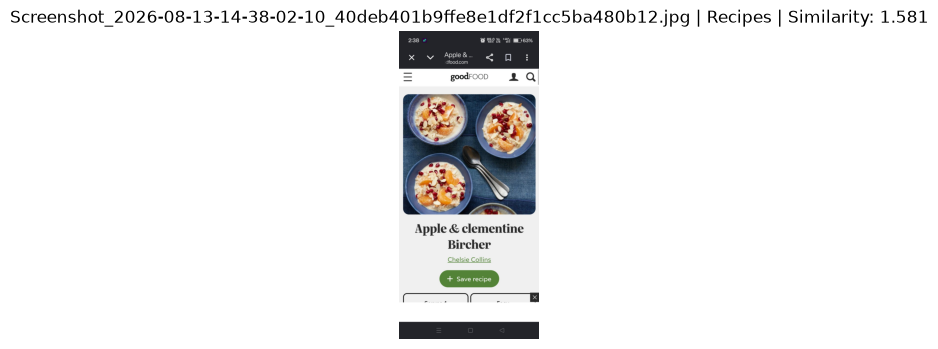

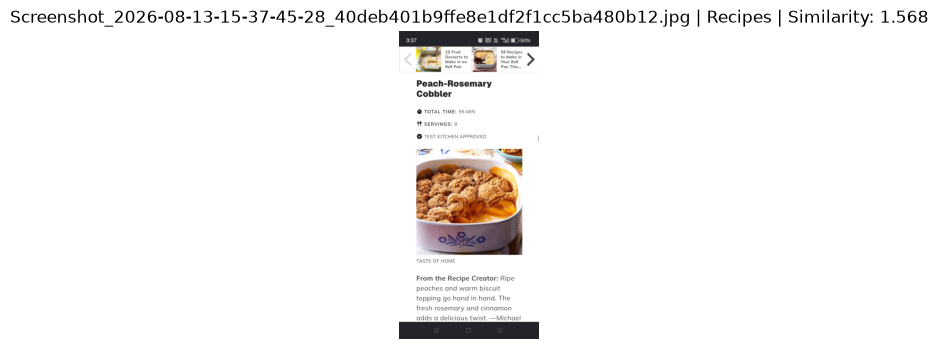

Search query: hotel booking


,filename,category,similarity
2034,IMG-20260813-WA0009.jpg,Tickets_Bookings,1.561047
2036,IMG-20260813-WA0011.jpg,Tickets_Bookings,1.517043
2231,IMG-20260813-WA0214.jpg,Tickets_Bookings,1.510484


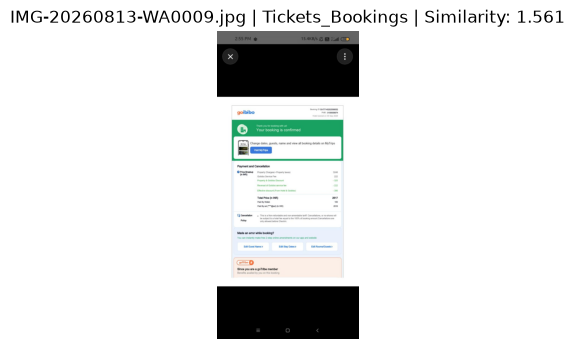

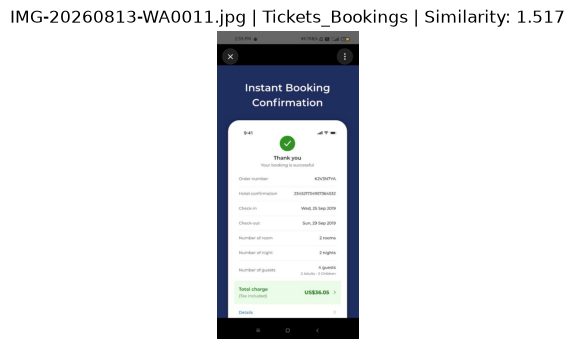

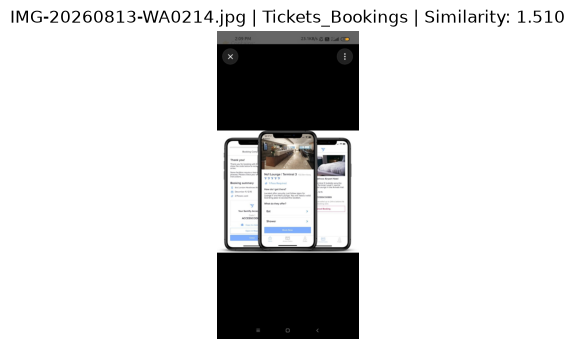

Search query: modern interior


,filename,category,similarity
412,IMG-20260813-WA1212.jpg,Interior_Design,1.660406
677,IMG-20260813-WA1792.jpg,Interior_Design,1.645593
625,IMG-20260813-WA1740.jpg,Interior_Design,1.596949


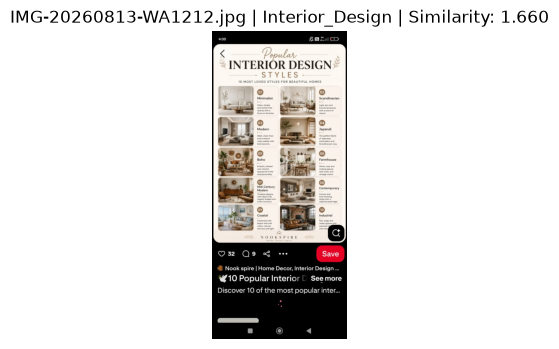

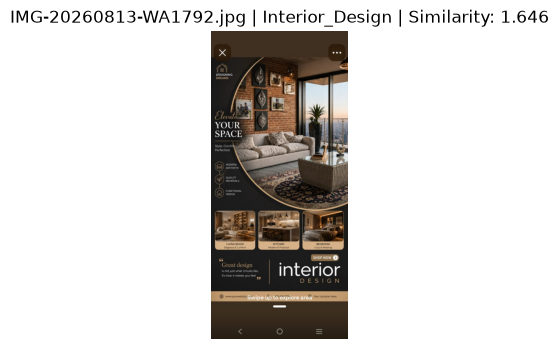

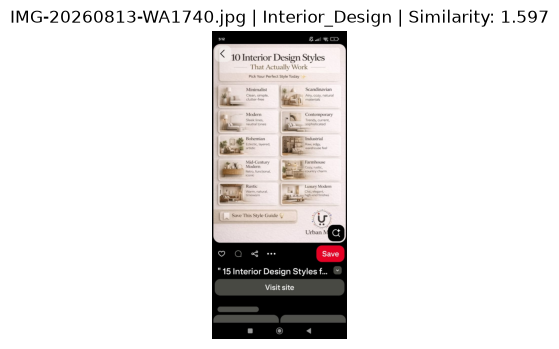

In [53]:
search_and_show("product shopping")
search_and_show("shopping bill")
search_and_show("address location")
search_and_show("recipe")
search_and_show("hotel booking")
search_and_show("modern interior")

In [54]:
import numpy as np

embeddings_path = r"C:\Users\Priyanka\OneDrive\Desktop\screenshot_embeddings.npy"

np.save(embeddings_path, embeddings)

print("Embeddings saved successfully!")
print("Shape:", embeddings.shape)
print("Saved at:", embeddings_path)

Embeddings saved successfully!
Shape: (2392, 384)
Saved at: C:\Users\Priyanka\OneDrive\Desktop\screenshot_embeddings.npy


In [55]:
metadata_save_path = r"C:\Users\Priyanka\OneDrive\Desktop\semantic_search_metadata.csv"

ocr_df.to_csv(metadata_save_path, index=False)

print("Metadata saved successfully!")
print("Rows:", len(ocr_df))

Metadata saved successfully!
Rows: 2392


In [56]:
print("Number of embeddings:", len(embeddings))
print("Number of metadata rows:", len(ocr_df))

Number of embeddings: 2392
Number of metadata rows: 2392
